# Fase 3 — Preparación de los Datos

Notebook con el **código y las visualizaciones** de la preparación de datos.

> Las **conclusiones y decisiones** están en `reports/03_preparacion_datos.md` (insumo del informe IEEE). Aquí solo código y figuras.

Decisiones: imagen **128×128**, desbalanceo con **class weights + augmentation**, features ML **color HSV + HOG**, split **70/15/15 estratificado por fruta×calidad**.

## 0. Configuración

In [1]:
import sys
from pathlib import Path
root = Path.cwd()
while not (root / 'src').exists() and root != root.parent:
    root = root.parent
sys.path.insert(0, str(root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from src.data.dataset import build_index, QUALITY_ORDER, QUALITY_PALETTE
from src.data import preprocess as pp

sns.set_theme(style='whitegrid')
print('IMG_SIZE =', pp.IMG_SIZE, '| SEED =', pp.SEED)

IMG_SIZE = (128, 128) | SEED = 42


## 1. Limpieza del índice (descartar corruptas y diminutas)

Antes : 9515 imágenes
Después: 7803 imágenes  (descartadas 1712)


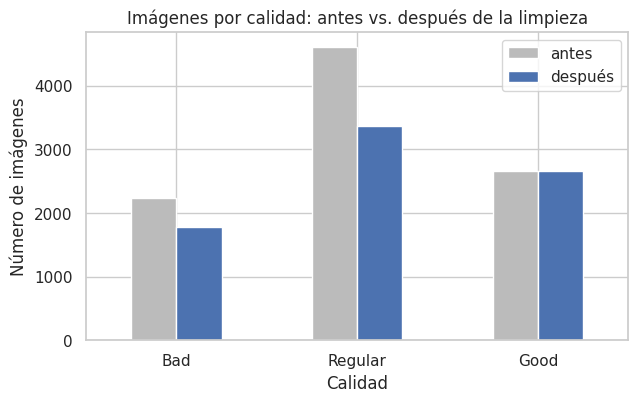

,antes,después
quality,,
Bad,2244,1774
Regular,4612,3370
Good,2659,2659


In [2]:
df_raw = build_index()
df = pp.clean_index(df_raw)
print(f'Antes : {len(df_raw)} imágenes')
print(f'Después: {len(df)} imágenes  (descartadas {len(df_raw)-len(df)})')

before = df_raw['quality'].value_counts().reindex(QUALITY_ORDER)
after  = df['quality'].value_counts().reindex(QUALITY_ORDER)
comp = pd.DataFrame({'antes': before, 'después': after})

fig, ax = plt.subplots(figsize=(7, 4))
comp.plot(kind='bar', ax=ax, color=['#bbbbbb', '#4c72b0'])
ax.set_title('Imágenes por calidad: antes vs. después de la limpieza')
ax.set_xlabel('Calidad'); ax.set_ylabel('Número de imágenes')
plt.xticks(rotation=0); plt.show()
comp

## 2. Splits estratificados (train/val/test = 70/15/15)

Conteo por calidad y split:


split,train,val,test
quality,,,
Bad,1242,266,266
Regular,2358,506,506
Good,1861,399,399


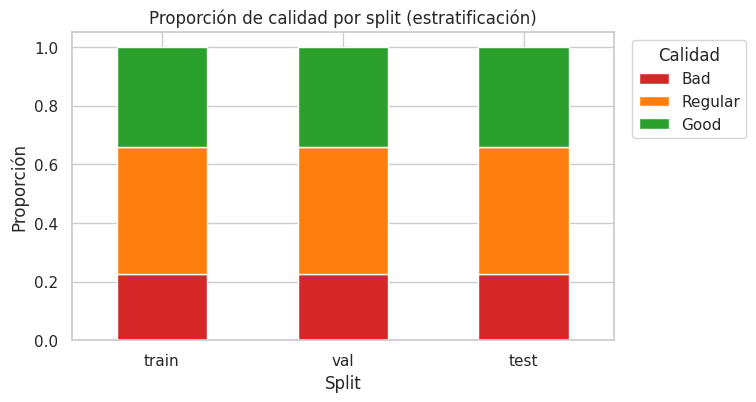

Tamaño de cada split:
split
train    5461
test     1171
val      1171
Name: count, dtype: int64


In [3]:
df = pp.make_splits(df)
tab = pd.crosstab(df['quality'], df['split']).reindex(QUALITY_ORDER)[['train','val','test']]
print('Conteo por calidad y split:'); display(tab)

# Proporciones por split (verificación de estratificación)
prop = pd.crosstab(df['split'], df['quality'], normalize='index')[QUALITY_ORDER]
prop = prop.reindex(['train','val','test'])
fig, ax = plt.subplots(figsize=(7, 4))
prop.plot(kind='bar', stacked=True, ax=ax,
          color=[QUALITY_PALETTE[q] for q in QUALITY_ORDER])
ax.set_title('Proporción de calidad por split (estratificación)')
ax.set_xlabel('Split'); ax.set_ylabel('Proporción')
ax.legend(title='Calidad', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0); plt.show()
print('Tamaño de cada split:'); print(df['split'].value_counts())

## 3. Pesos de clase (manejo del desbalanceo)

Pesos de clase (balanced):
  Bad     : 1.466
  Regular : 0.772
  Good    : 0.978


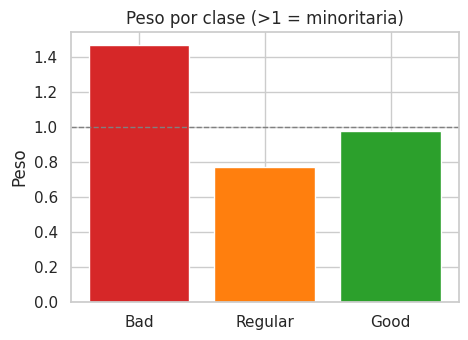

In [4]:
train_labels = df[df['split']=='train']['quality']
weights = pp.class_weights(train_labels)
print('Pesos de clase (balanced):')
for k in QUALITY_ORDER:
    print(f'  {k:8s}: {weights[k]:.3f}')

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(QUALITY_ORDER, [weights[k] for k in QUALITY_ORDER],
       color=[QUALITY_PALETTE[q] for q in QUALITY_ORDER])
ax.axhline(1.0, color='gray', ls='--', lw=1)
ax.set_title('Peso por clase (>1 = minoritaria)'); ax.set_ylabel('Peso')
plt.show()

## 4. Pipeline de preprocesamiento de una imagen

Ejemplo con una imagen RGBA (clase Regular) para mostrar el aplanado del canal alfa, el redimensionado a 128×128 y la normalización.

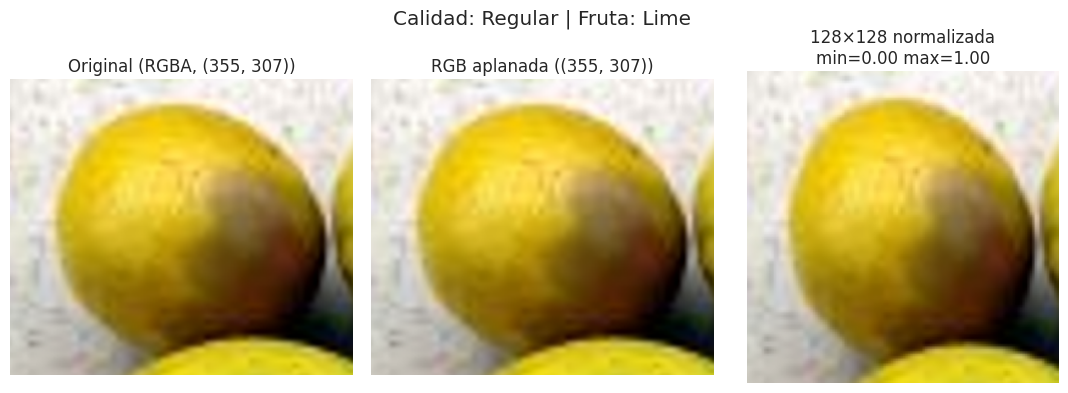

In [5]:
rgba_rows = df[df['mode']=='RGBA']
row = rgba_rows.iloc[0]
orig = Image.open(root / row['path'])
flat = pp.load_rgb(row['path'])                 # RGBA -> RGB (fondo blanco)
arr  = pp.load_image_array(row['path'])         # 128x128, [0,1]

fig, axes = plt.subplots(1, 3, figsize=(11, 4))
axes[0].imshow(orig); axes[0].set_title(f'Original ({orig.mode}, {orig.size})')
axes[1].imshow(flat); axes[1].set_title(f'RGB aplanada ({flat.size})')
axes[2].imshow(arr);  axes[2].set_title(f'128×128 normalizada\nmin={arr.min():.2f} max={arr.max():.2f}')
for a in axes: a.axis('off')
plt.suptitle(f"Calidad: {row['quality']} | Fruta: {row['fruit']}")
plt.tight_layout(); plt.show()

## 5. Data augmentation (ejemplos)

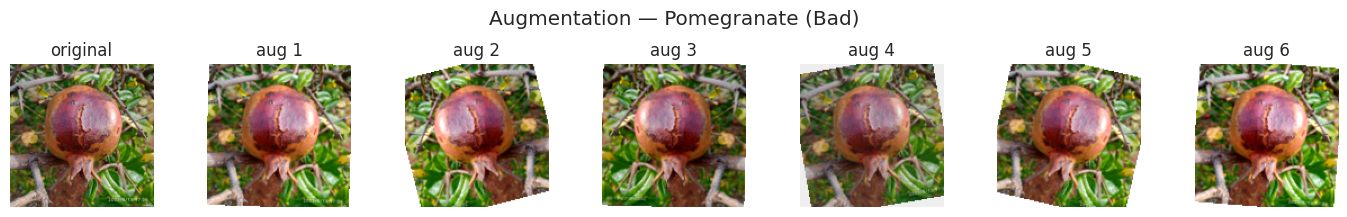

In [6]:
sample = df[(df['split']=='train')].sample(1, random_state=pp.SEED).iloc[0]
base = pp.load_rgb(sample['path'], size=pp.IMG_SIZE)
rng = np.random.default_rng(pp.SEED)

n = 6
fig, axes = plt.subplots(1, n+1, figsize=(2.0*(n+1), 2.2))
axes[0].imshow(base); axes[0].set_title('original'); axes[0].axis('off')
for i in range(1, n+1):
    aug = pp.augment_image(base, rng)
    axes[i].imshow(aug); axes[i].set_title(f'aug {i}'); axes[i].axis('off')
plt.suptitle(f"Augmentation — {sample['fruit']} ({sample['quality']})")
plt.tight_layout(); plt.show()

## 6. Descriptores para ML tradicional (color HSV + HOG)

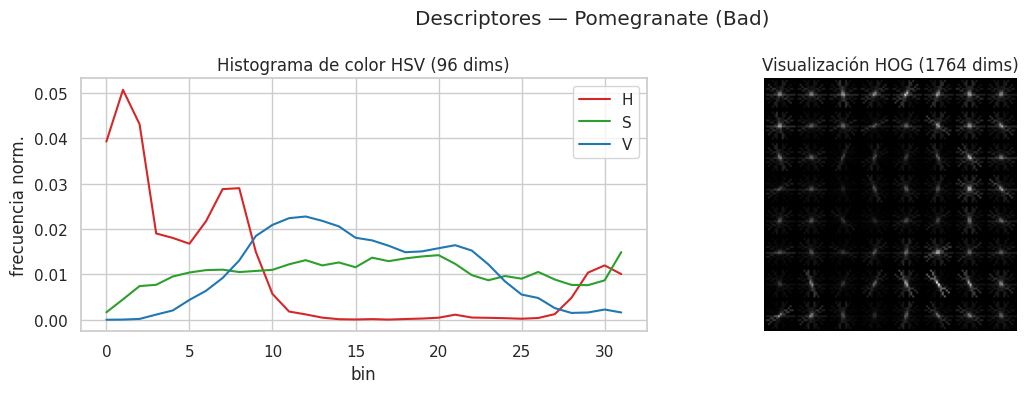

In [7]:
arr = pp.load_image_array(sample['path'])

# --- Histograma de color HSV ---
hsv_vec = pp.color_hist_hsv(arr)
bins = pp.HSV_BINS
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(bins)
for ci, (name, col) in enumerate(zip(['H','S','V'], ['#d62728','#2ca02c','#1f77b4'])):
    axes[0].plot(x, hsv_vec[ci*bins:(ci+1)*bins], label=name, color=col)
axes[0].set_title(f'Histograma de color HSV ({3*bins} dims)')
axes[0].set_xlabel('bin'); axes[0].set_ylabel('frecuencia norm.'); axes[0].legend()

# --- HOG ---
hog_vec, hog_img = pp.hog_features(arr, visualize=True)
axes[1].imshow(hog_img, cmap='gray')
axes[1].set_title(f'Visualización HOG ({hog_vec.size} dims)'); axes[1].axis('off')
plt.suptitle(f"Descriptores — {sample['fruit']} ({sample['quality']})")
plt.tight_layout(); plt.show()

## 7. Dimensión del vector de características y prueba sobre una muestra

In [8]:
# Vector completo (color + HOG) de una imagen
full = np.concatenate([pp.color_hist_hsv(arr), pp.hog_features(arr)])
print(f'Color HSV : {3*pp.HSV_BINS} dims')
print(f'HOG       : {pp.hog_features(arr).size} dims')
print(f'TOTAL     : {full.size} dims por imagen')

# Prueba rápida de extract_features sobre una muestra pequeña (30 imágenes)
demo = df[df['split']=='train'].sample(30, random_state=pp.SEED)
X_demo, y_demo = pp.extract_features(demo, verbose=False)
print(f'\nMatriz de prueba X: {X_demo.shape} | etiquetas y: {y_demo.shape}')
print('Clases en la muestra:', dict(zip(*np.unique(y_demo, return_counts=True))))

Color HSV : 96 dims
HOG       : 1764 dims
TOTAL     : 1860 dims por imagen



Matriz de prueba X: (30, 1860) | etiquetas y: (30,)
Clases en la muestra: {np.str_('Bad'): np.int64(7), np.str_('Good'): np.int64(8), np.str_('Regular'): np.int64(15)}
